retail_sales_eda.ipynb
│
├── Cell 1  → Libraries
├── Cell 2  → Load Dataset
├── Cell 3  → Inspection
├── Cell 4  → Cleaning
├── Cell 5  → Statistics
├── Cell 6  → Monthly Sales
├── Cell 7  → Quarterly Sales
├── Cell 8  → Age Groups
├── Cell 9  → Gender
├── Cell 10 → Top 10 Products
├── Cell 11 → Revenue Category
├── Cell 12 → Heatmap
├── Cell 13 → Additional Visualization
├── Cell 14 → Business Summary
└── Cell 15 → Conclusion & Recommendations

In [25]:
total_revenue = df["Total Amount"].sum()
average_transaction = df["Total Amount"].mean()
total_quantity = df["Quantity"].sum()

print("========== BUSINESS SUMMARY ==========")
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Average Transaction: {average_transaction:,.2f}")
print(f"Total Units Sold: {total_quantity:,.0f}")
print(f"Total Records: {len(df):,}")

========== BUSINESS SUMMARY ==========
Total Revenue: 780,722.05
Average Transaction: 780.72
Total Units Sold: 2,963
Total Records: 1,000


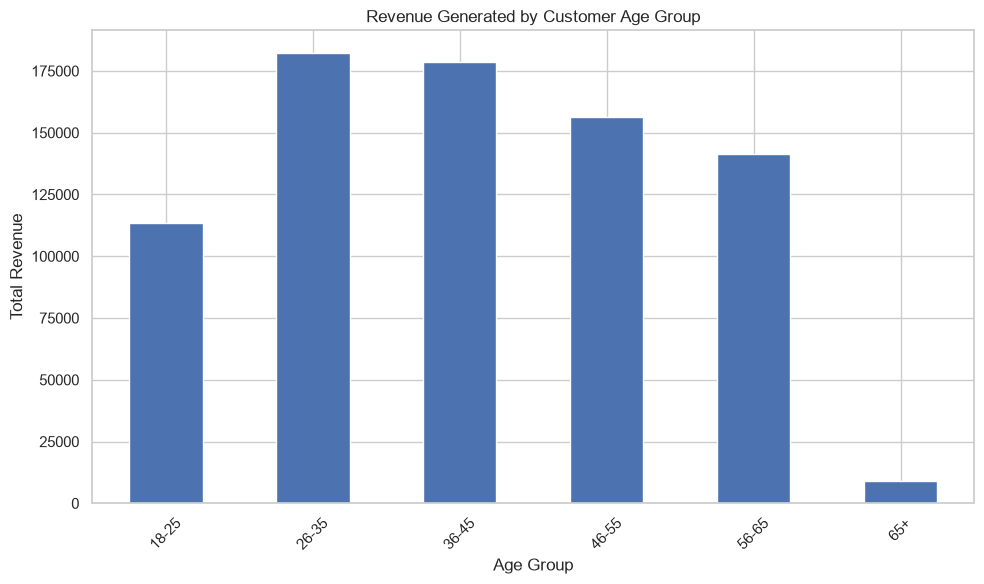

In [24]:
age_revenue = (
    df.groupby("Age Group", observed=True)["Total Amount"]
    .sum()
)

plt.figure(figsize=(10, 6))

age_revenue.plot(kind="bar")

plt.title("Revenue Generated by Customer Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

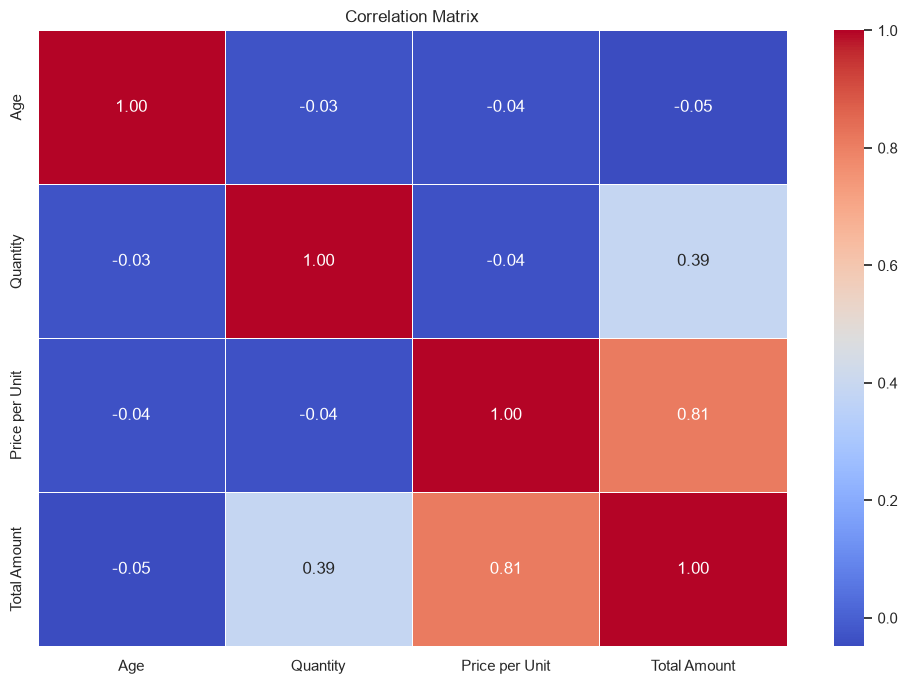

In [23]:
numeric_data = df.select_dtypes(include=np.number)

correlation_matrix = numeric_data.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

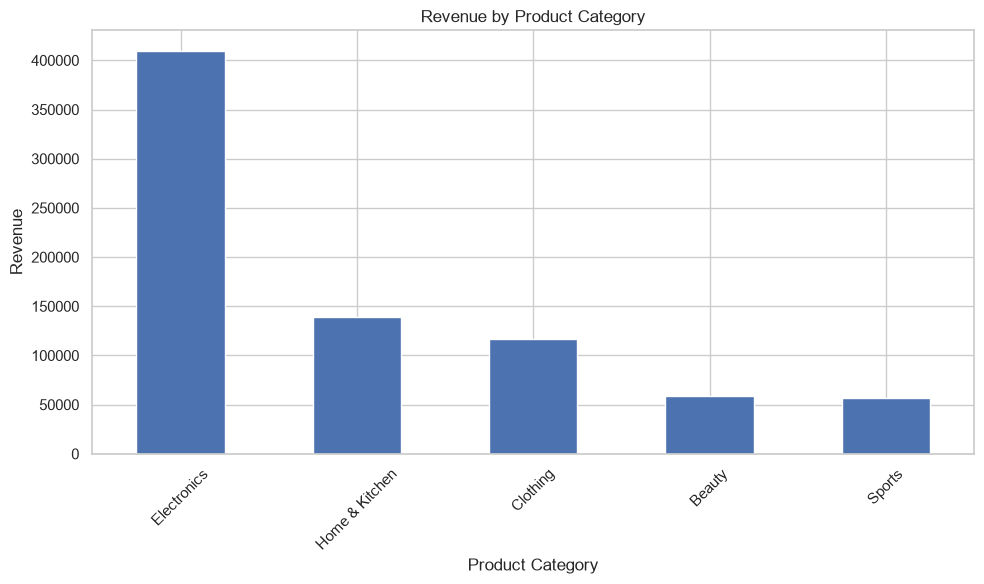

In [22]:
category_revenue = (
    df.groupby("Product Category")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

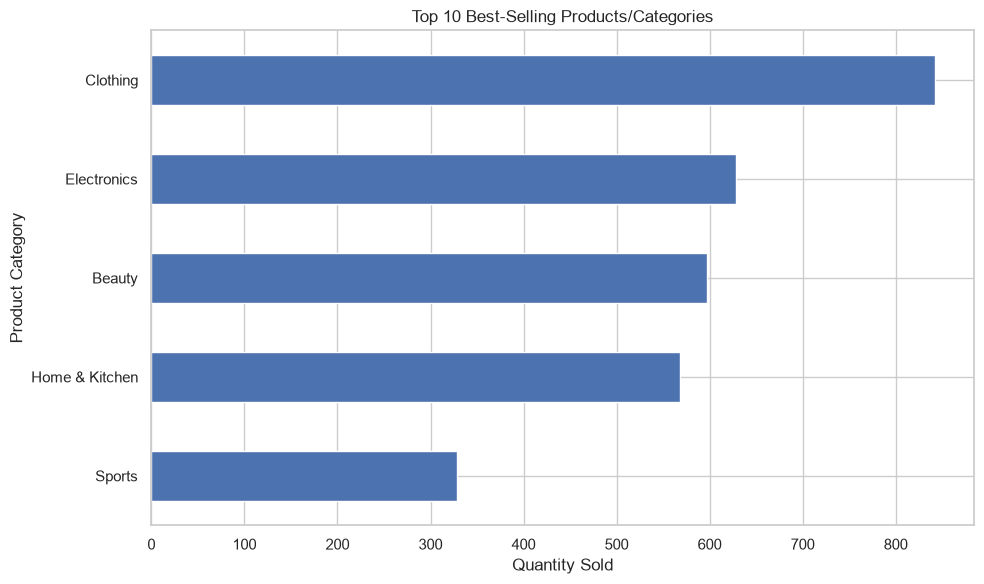

Product Category
Clothing          842
Electronics       628
Beauty            597
Home & Kitchen    568
Sports            328
Name: Quantity, dtype: int64

In [21]:
top_products = (
    df.groupby("Product Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Best-Selling Products/Categories")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

display(top_products)

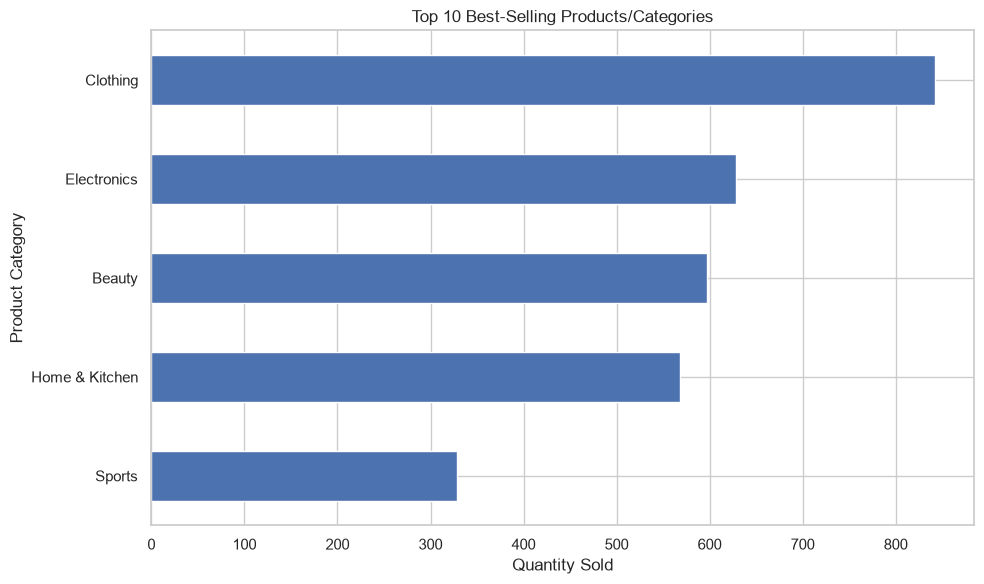

Product Category
Clothing          842
Electronics       628
Beauty            597
Home & Kitchen    568
Sports            328
Name: Quantity, dtype: int64

In [20]:
top_products = (
    df.groupby("Product Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Best-Selling Products/Categories")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

display(top_products)

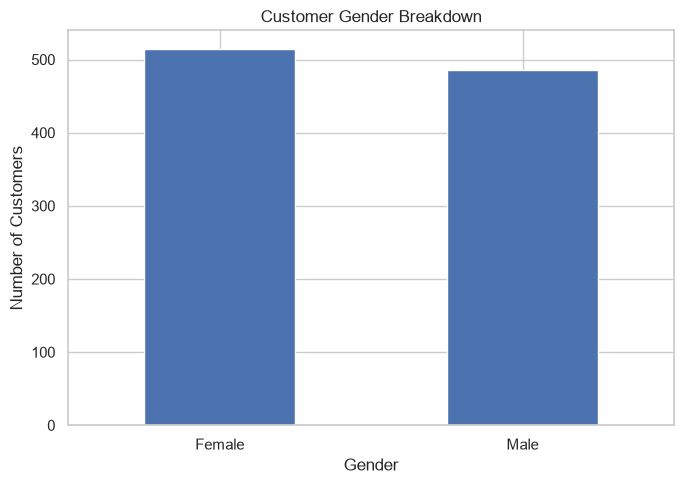

In [19]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(7, 5))
gender_counts.plot(kind="bar")

plt.title("Customer Gender Breakdown")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

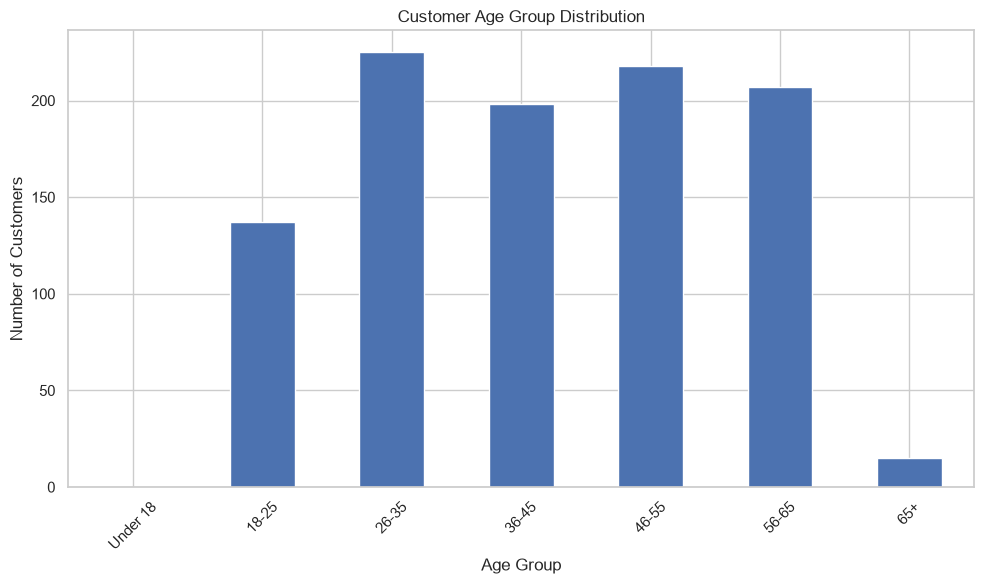

In [18]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]

labels = [
    "Under 18",
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "65+"
]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    right=False
)

age_groups = df["Age Group"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
age_groups.plot(kind="bar")

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

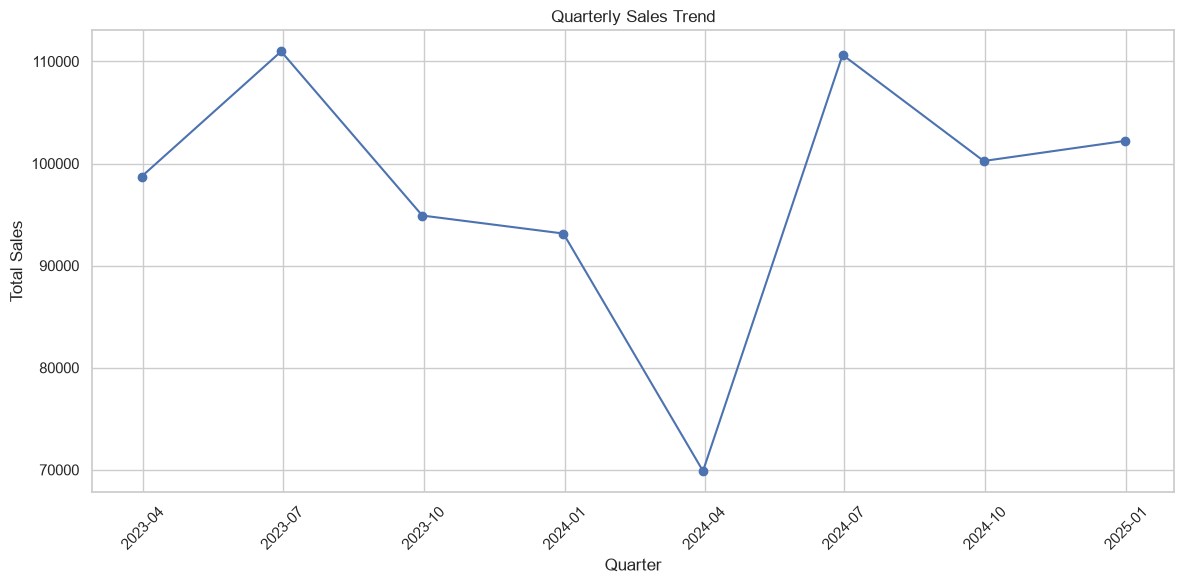

In [17]:
quarterly_sales = (
    df.set_index("Date")
    .resample("QE")["Total Amount"]
    .sum()
)

plt.figure(figsize=(12, 6))
plt.plot(
    quarterly_sales.index,
    quarterly_sales.values,
    marker="o"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

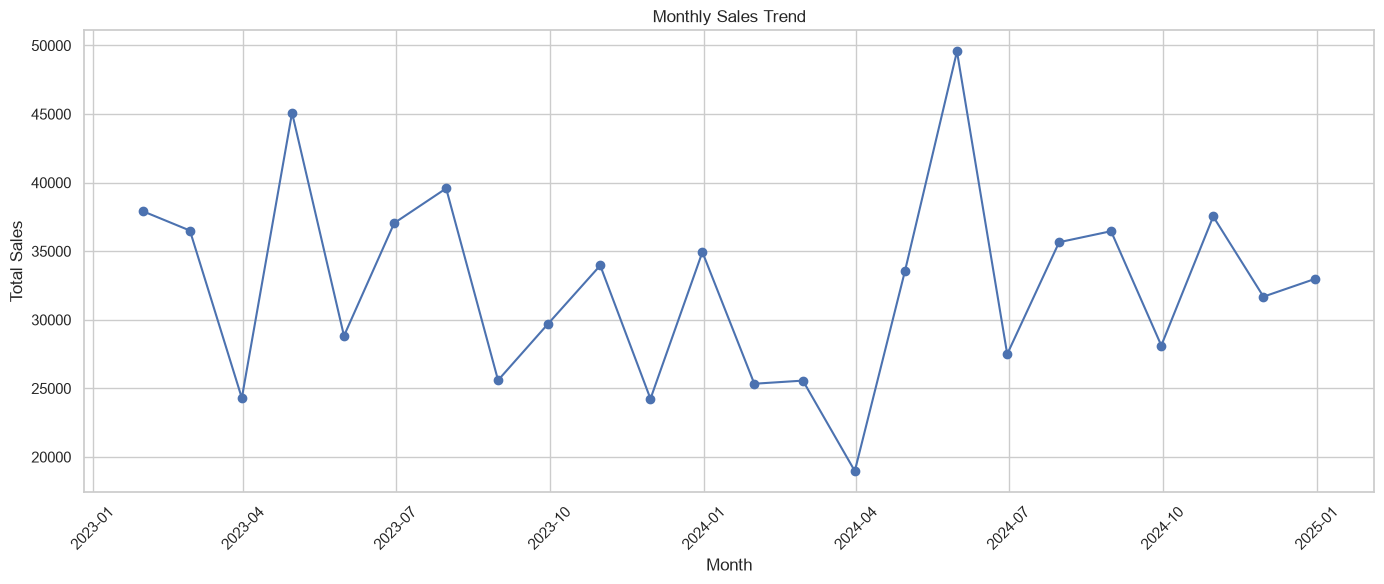

In [16]:
monthly_sales = (
    df.set_index("Date")
    .resample("ME")["Total Amount"]
    .sum()
)

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [15]:
numeric_columns = df.select_dtypes(include=np.number).columns

statistics = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Standard Deviation": df[numeric_columns].std()
})

display(statistics)

,Mean,Median,Mode,Standard Deviation
Age,41.46500,42.00,25.00,13.750631
Quantity,2.96300,3.00,2.00,1.425364
Price per Unit,268.13802,168.17,124.79,273.823079
Total Amount,780.72205,452.90,103.06,947.489909


In [14]:
numeric_columns = df.select_dtypes(include=np.number).columns

statistics = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Standard Deviation": df[numeric_columns].std()
})

display(statistics)

,Mean,Median,Mode,Standard Deviation
Age,41.46500,42.00,25.00,13.750631
Quantity,2.96300,3.00,2.00,1.425364
Price per Unit,268.13802,168.17,124.79,273.823079
Total Amount,780.72205,452.90,103.06,947.489909


In [13]:
df = df.drop_duplicates()

if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("Data cleaning completed!")
print(df.info())

Data cleaning completed!
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              1000 non-null   datetime64[us]
 1   Gender            1000 non-null   str           
 2   Age               1000 non-null   int64         
 3   Product           1000 non-null   str           
 4   Product Category  1000 non-null   str           
 5   Quantity          1000 non-null   int64         
 6   Price per Unit    1000 non-null   float64       
 7   Total Amount      1000 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(3)
memory usage: 62.6 KB
None


In [12]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape: (1000, 8)

Data Types:
Date                    str
Gender                  str
Age                   int64
Product                 str
Product Category        str
Quantity              int64
Price per Unit      float64
Total Amount        float64
dtype: object

Missing Values:
Date                0
Gender              0
Age                 0
Product             0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate Rows:
0


In [11]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape: (1000, 8)

Data Types:
Date                    str
Gender                  str
Age                   int64
Product                 str
Product Category        str
Quantity              int64
Price per Unit      float64
Total Amount        float64
dtype: object

Missing Values:
Date                0
Gender              0
Age                 0
Product             0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate Rows:
0


In [10]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape: (1000, 8)

Data Types:
Date                    str
Gender                  str
Age                   int64
Product                 str
Product Category        str
Quantity              int64
Price per Unit      float64
Total Amount        float64
dtype: object

Missing Values:
Date                0
Gender              0
Age                 0
Product             0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate Rows:
0


In [9]:
df = pd.read_csv("retail_sales_dataset.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (1000, 8)


,Date,Gender,Age,Product,Product Category,Quantity,Price per Unit,Total Amount
0,2023-01-01,Male,64,Shoes,Clothing,5,51.84,259.20
1,2023-01-01,Female,29,T-Shirt,Clothing,2,153.13,306.26
2,2023-01-02,Female,33,Smartwatch,Electronics,1,726.43,726.43
3,2023-01-03,Female,41,Football,Sports,3,306.58,919.74
4,2023-01-03,Male,36,Face Cream,Beauty,3,74.45,223.35


In [7]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")    



print("Libraries imported successfully!")

Libraries imported successfully!
